In [1]:
# Set up notebook for animation
%matplotlib inline

In [2]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt
import random
from collections import defaultdict
from matplotlib.animation import FuncAnimation
import networkx as nx
import matplotlib.cm as cm
from collections import Counter

In [ ]:
# Model Parameters (global)

# Interaction rules
interaction_radius = 2.0                    # Max distance to allow interaction
min_shared = 0.02                           # Minimum shared language for interaction (after threshold_start)
threshold_start = 5                         # Round when shared language threshold kicks in

# Shared language dynamics
decay_rate = 0.5                           # Decay rate for unused ties
max_shared_weight = 1.0                     # Cap on shared language strength

# Movement rules
move_strength = 0.1                         # How strongly shared language pulls agents
max_movement = 0.5                          # Maximum distance an agent can move in a round

# Clustering
language_cluster_threshold = 0.1           # Threshold for edge inclusion in clustering

# Animation
num_steps = 50                              # Number of animation frames
num_agents = 50                             # Total number of agents
grid_size = 10                              # Spatial domain

# Repeat interaction preference distribution
repeat_pref_mean = 1.5    # positive = prefers known partners
repeat_pref_std = 0.25     # variation across agents

In [ ]:
# === Case 1: No Convergence (everyone speaks their own language) ===
# Interaction rules
interaction_radius = 0.5                    # Max distance to allow interaction
min_shared = 0.05                           # Minimum shared language for interaction (after threshold_start)
threshold_start = 2                         # Round when shared language threshold kicks in

# Shared language dynamics
decay_rate = 0.9                           # Decay rate for unused ties
max_shared_weight = 1.0                     # Cap on shared language strength

# Movement rules
move_strength = 0.1                         # How strongly shared language pulls agents
max_movement = 0.5                          # Maximum distance an agent can move in a round

# Clustering
language_cluster_threshold = 0.1           # Threshold for edge inclusion in clustering

# Animation
num_steps = 50                              # Number of animation frames
num_agents = 50                             # Total number of agents
grid_size = 10                              # Spatial domain

# Repeat interaction preference distribution
repeat_pref_mean = 1.0    # positive = prefers known partners
repeat_pref_std = 0.5     # variation across agents

In [ ]:
# === Case 2: Some Regional Convergence (one large cluster) ===
interaction_radius = 3.0        # Moderate: neighbors can interact
min_shared = 0.02               # Lenient threshold after delay
threshold_start = 5             # Gives time for initial random mixing

decay_rate = 0.01               # Mild decay
max_shared_weight = 1.0         # Allows strong shared language

move_strength = 0.1             # Agents slowly cluster together
max_movement = 0.5              # Reasonable mobility

language_cluster_threshold = 0.05
num_steps = 50
num_agents = 50
grid_size = 10

# # Repeat interaction preference distribution
repeat_pref_mean = 1.0    # positive = prefers known partners
repeat_pref_std = 0.25     # variation across agents

In [3]:
# === Case 3: Some Regional Convergence (several medium-sized clusters) ===
interaction_radius = 2.0        # Moderate: neighbors can interact
min_shared = 0.02               # Lenient threshold after delay
threshold_start = 10             # Gives time for initial random mixing

decay_rate = 0.01               # Mild decay
max_shared_weight = 1.0         # Allows strong shared language

move_strength = 0.1             # Agents slowly cluster together
max_movement = 0.5              # Reasonable mobility

language_cluster_threshold = 0.05
num_steps = 50
num_agents = 50
grid_size = 10

# Repeat interaction preference distribution
repeat_pref_mean = 1.0    # positive = prefers known partners
repeat_pref_std = 0.5     # variation across agents

In [ ]:
# === Case 4: Global Convergence (everyone speaks the same language) ===
interaction_radius = 5.0        # Very large: everyone can interact with everyone
min_shared = 0.0                # No minimum barrier to interaction
threshold_start = 100           # Never enforced (effectively off)

decay_rate = 0.0                # No decay at all
max_shared_weight = 1.0         # Strong mutual reinforcement

move_strength = 0.3             # Strong pull toward shared speakers
max_movement = 1.0              # Agents quickly converge spatially

language_cluster_threshold = 0.05
num_steps = 50
num_agents = 50
grid_size = 10

# Repeat interaction preference distribution
repeat_pref_mean = 1.0    # positive = prefers known partners
repeat_pref_std = 0.5     # variation across agents

In [4]:
# Define Agents

class Agent:
    def __init__(self, agent_id, x, y, repeat_pref_weight):
        self.id = agent_id
        self.position = np.array([x, y])
        self.repeat_pref_weight = repeat_pref_weight

In [5]:
# Define Model

class AgentModel:
    def __init__(self, num_agents, grid_size,
                 repeat_pref_mean, repeat_pref_std,
                 interaction_radius, min_shared, threshold_start,
                 decay_rate, max_shared_weight,
                 move_strength, max_movement, language_cluster_threshold):

        self.grid_size = grid_size
        self.interaction_radius = interaction_radius
        self.min_shared = min_shared
        self.threshold_start = threshold_start
        self.decay_rate = decay_rate
        self.max_shared_weight = max_shared_weight
        self.move_strength = move_strength
        self.max_movement = max_movement
        self.language_cluster_threshold = language_cluster_threshold
        self.round_counter = 0

        self.agents = [
            Agent(
                i,
                *np.random.rand(2) * grid_size,
                np.random.normal(repeat_pref_mean, repeat_pref_std)
            )
            for i in range(num_agents)
        ]

        self.shared_language = defaultdict(float)
        self.cluster_history = []
        self.interaction_counts = defaultdict(int)

    # Define interaction rule
    def interact(self, min_shared, threshold_start, interaction_radius):
        num_agents = len(self.agents)
        positions = np.array([agent.position for agent in self.agents])
        probs = np.zeros((num_agents, num_agents))
        use_threshold = self.round_counter >= threshold_start

        for i, a1 in enumerate(self.agents):
            for j, a2 in enumerate(self.agents):
                if i == j:
                    continue

                distance = np.linalg.norm(positions[i] - positions[j])
                if distance > interaction_radius:
                    continue  # Too far to interact

                key = tuple(sorted((a1.id, a2.id)))
                shared = self.shared_language[key]

                if not use_threshold or shared >= min_shared:
                    #probs[i, j] = 0.01 + shared  # base chance + familiarity
                    weight = a1.repeat_pref_weight  # agent a1’s preference for repeat interactions
                    base_prob = 0.01
                    probs[i, j] = max(0.0, base_prob + weight * shared)

            row_sum = probs[i].sum()
            if row_sum > 0:
                probs[i] /= row_sum
            else:
                probs[i] = np.zeros(num_agents)

        paired = set()
        for i, a1 in enumerate(self.agents):
            if a1.id in paired or probs[i].sum() == 0:
                continue
            partner_idx = np.random.choice(num_agents, p=probs[i])
            a2 = self.agents[partner_idx]
            if a2.id not in paired and a1.id != a2.id:
                key = tuple(sorted((a1.id, a2.id)))
                self.shared_language[key] += 0.05
                self.interaction_counts[key] += 1
                paired.update([a1.id, a2.id])

        self.round_counter += 1

    def move_agents(self, strength, max_step):
        for agent in self.agents:
            pull = np.zeros(2)
            for other in self.agents:
                if agent.id != other.id:
                    key = tuple(sorted((agent.id, other.id)))
                    shared = self.shared_language[key]
                    direction = other.position - agent.position
                    pull += shared * direction

            # Scale by strength
            pull *= strength

            # Limit movement to max_step
            step_norm = np.linalg.norm(pull)
            if step_norm > max_step:
                pull = pull / step_norm * max_step

            agent.position += pull
            agent.position = np.clip(agent.position, 0, self.grid_size)

    def decay_and_reinforce(self, decay=decay_rate, max_weight=max_shared_weight):
        """Decays weaker ties and caps reinforcement based on normalized strength."""
        # Temporary store to track total attention budget per agent
        attention = {agent.id: [] for agent in self.agents}

        # Collect all current shared language ties
        for (id1, id2), val in self.shared_language.items():
            attention[id1].append((id2, val))
            attention[id2].append((id1, val))

        # Normalize and decay
        for agent in self.agents:
            ties = attention[agent.id]
            total = sum(val for _, val in ties)

            for other_id, val in ties:
                key = tuple(sorted((agent.id, other_id)))

                if total == 0:
                    continue

                # How much "attention" this tie gets from this agent
                attention_share = val / total

                # If attention is below threshold, let it decay
                if attention_share < 1 / len(self.agents):
                    self.shared_language[key] = max(0, self.shared_language[key] - decay)

                # Optional: cap maximum value
                self.shared_language[key] = min(self.shared_language[key], max_weight)

    def get_language_clusters(self, threshold=language_cluster_threshold):
        """Return a list of cluster IDs for each agent based on shared language."""
        G = nx.Graph()
        for agent in self.agents:
            G.add_node(agent.id)

        # Add edges for agents with strong enough shared language
        for (id1, id2), val in self.shared_language.items():
            if val >= threshold:
                G.add_edge(id1, id2, weight=val)

        # Use connected components as clusters
        components = list(nx.connected_components(G))
        id_to_cluster = {}
        for cluster_id, component in enumerate(components):
            for agent_id in component:
                id_to_cluster[agent_id] = cluster_id

        # Map each agent to their cluster
        return [id_to_cluster.get(agent.id, -1) for agent in self.agents]

    # Compute complexity by interaction share (languages with more speakers develop more complexity)
    def compute_complexity_by_interaction_share(self):
        """Returns {cluster_id: (complexity_score, cluster_size)}
        where complexity is share of all interactions."""

        cluster_ids = self.get_language_clusters(threshold=0.05)
        clusters = {}
        for agent, cid in zip(self.agents, cluster_ids):
            clusters.setdefault(cid, []).append(agent.id)

        total_interactions = sum(self.interaction_counts.values())

        results = {}

        for cid, members in clusters.items():
            n = len(members)
            if n < 2 or total_interactions == 0:
                results[cid] = (0, n)
                continue

            cluster_interactions = 0
            for i in range(n):
                for j in range(i + 1, n):
                    key = tuple(sorted((members[i], members[j])))
                    cluster_interactions += self.interaction_counts[key]

            complexity = cluster_interactions / total_interactions
            results[cid] = (complexity, n)

        return results



    # # Compute language complexity by internal weighted density (languages with fewer speakers develop more complexity)
    #
    # def compute_language_complexities(self, threshold=0.05):
    #   """Returns a dict of {cluster_id: (complexity_score, cluster_size)}."""
    #   G = nx.Graph()
    #   for agent in self.agents:
    #       G.add_node(agent.id)

    #   for (id1, id2), weight in self.shared_language.items():
    #       if weight >= threshold:
    #           G.add_edge(id1, id2, weight=weight)

    #   clusters = list(nx.connected_components(G))
    #   complexities = {}

    #   for cid, members in enumerate(clusters):
    #       members = list(members)
    #       n = len(members)
    #       if n < 2:
    #           complexities[cid] = (0, n)
    #           continue

    #       internal_weight_sum = 0
    #       for i in range(n):
    #           for j in range(i + 1, n):
    #               a, b = members[i], members[j]
    #               key = tuple(sorted((a, b)))
    #               if key in self.shared_language:
    #                   internal_weight_sum += self.shared_language[key]

    #       max_possible_pairs = n * (n - 1) / 2
    #       complexity_score = internal_weight_sum / max_possible_pairs if max_possible_pairs > 0 else 0
    #       complexities[cid] = (complexity_score, n)

    #   return complexities

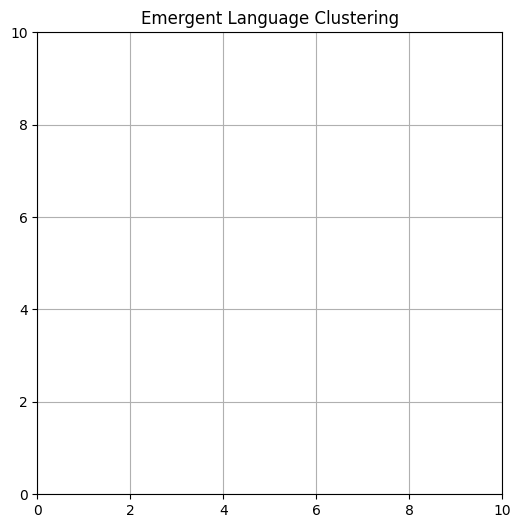

In [6]:
# Initialize model
model = AgentModel(num_agents=num_agents,
                   grid_size=grid_size,
                   repeat_pref_mean=repeat_pref_mean,
                   repeat_pref_std=repeat_pref_std,
                   interaction_radius = interaction_radius,
                   min_shared = min_shared,
                   threshold_start = threshold_start,
                   decay_rate = decay_rate,
                   max_shared_weight = max_shared_weight,
                   move_strength = move_strength,
                   max_movement = max_movement,
                   language_cluster_threshold = language_cluster_threshold
                  )

# Setup matplotlib figure
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter([], [], c='blue')
ax.set_xlim(0, model.grid_size)
ax.set_ylim(0, model.grid_size)
ax.grid(True)
ax.set_title("Emergent Language Clustering")

def init():
    sc.set_offsets(np.empty((0, 2)))
    return sc,

def update(frame):
    model.interact(
        min_shared=min_shared,
        threshold_start=threshold_start,
        interaction_radius=interaction_radius
    )
    model.decay_and_reinforce(
        decay=decay_rate,
        max_weight=max_shared_weight
    )
    model.move_agents(
        strength=move_strength,
        max_step=max_movement
    )

    positions = np.array([agent.position for agent in model.agents])
    cluster_ids = model.get_language_clusters(threshold=language_cluster_threshold)
    num_clusters = max(cluster_ids) + 1 if cluster_ids else 1

    cmap = plt.colormaps['tab10'].resampled(num_clusters)
    colors = [cmap(cid) if cid >= 0 else (0.5, 0.5, 0.5) for cid in cluster_ids]

    sc.set_offsets(positions)
    sc.set_color(colors)
    ax.set_title(f"Step {frame + 1} – Clusters: {num_clusters}")
    return sc,

In [7]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML
from google.colab import files

# Create animation
ani = FuncAnimation(fig, update, frames=num_steps, init_func=init, blit=False, interval=200, repeat=False)

# Save the animation to a .gif file
ani.save("language_emergence.gif", writer=PillowWriter(fps=5))

# Now download the saved file
files.download("language_emergence.gif")

# Also show the animation inline (optional)
HTML(ani.to_jshtml())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
# Compute language complexities

complexities = model.compute_complexity_by_interaction_share()
for cid, (score, size) in complexities.items():
    print(f"Language {cid}: Language Complexity = {score:.3f} (Size: {size})")

# complexities = model.compute_language_complexities(threshold=0.05)
# for cid, (score, size) in complexities.items():
#     print(f"Language {cid}: Language Complexity = {score:.3f} (Size: {size})")

Language 0: Language Complexity = 0.049 (Size: 2)
Language 1: Language Complexity = 0.049 (Size: 2)
Language 2: Language Complexity = 0.106 (Size: 6)
Language 3: Language Complexity = 0.049 (Size: 2)
Language 4: Language Complexity = 0.110 (Size: 6)
Language 5: Language Complexity = 0.097 (Size: 5)
Language 6: Language Complexity = 0.267 (Size: 14)
Language 7: Language Complexity = 0.130 (Size: 7)
Language 8: Language Complexity = 0.049 (Size: 2)
Language 9: Language Complexity = 0.048 (Size: 2)
Language 10: Language Complexity = 0.048 (Size: 2)


## **Comparative Statics: Preferential Attachment and Language Emergence**

In [9]:
# Wrap model in a single function

def run_language_model(repeat_pref_mean, repeat_pref_std, return_metrics=True):
    # Set global parameter values
    global num_agents, grid_size, num_steps
    global interaction_radius, min_shared, threshold_start
    global decay_rate, max_shared_weight
    global move_strength, max_movement
    global language_cluster_threshold

    # Initialize the model with current parameters
    model = AgentModel(
        num_agents=num_agents,
        grid_size=grid_size,
        repeat_pref_mean=repeat_pref_mean,
        repeat_pref_std=repeat_pref_std,
        interaction_radius=interaction_radius,
        min_shared=min_shared,
        threshold_start=threshold_start,
        decay_rate=decay_rate,
        max_shared_weight=max_shared_weight,
        move_strength=move_strength,
        max_movement=max_movement,
        language_cluster_threshold=language_cluster_threshold
    )

    for step in range(num_steps):
        model.interact(
            min_shared=min_shared,
            threshold_start=threshold_start,
            interaction_radius=interaction_radius
        )
        model.decay_and_reinforce(
            decay=decay_rate,
            max_weight=max_shared_weight
        )
        model.move_agents(
            strength=move_strength,
            max_step=max_movement
        )

    # if return_metrics:
    #     clusters = model.get_language_clusters()
    #     complexities = model.compute_complexity_by_interaction_share()
    #     num_clusters = len(clusters)
    #     avg_complexity = np.mean(list(complexities.values())) if complexities else 0
    #     return {'mean': repeat_pref_mean, 'std': repeat_pref_std, 'clusters': num_clusters, 'complexity': avg_complexity}
    # else:
    #     return model


    # if return_metrics:
    #   complexities = model.compute_complexity_by_interaction_share()
    #   num_clusters = len(complexities)
    #   avg_complexity = np.mean([score for score, size in complexities.values()])
    #   largest_cluster = max(cluster_counts.values()) if cluster_counts else 0
    #   return {
    #       'mean': repeat_pref_mean,
    #       'std': repeat_pref_std,
    #       'clusters': num_clusters,
    #       'avg_complexity': avg_complexity,
    #       'largest_cluster': largest_cluster
    #   }
    # else:
    #     return model


    if return_metrics:
      complexities = model.compute_complexity_by_interaction_share()
      cluster_ids = model.get_language_clusters(threshold=language_cluster_threshold)
      cluster_counts = Counter(cluster_ids)
      largest_cluster = max(cluster_counts.values()) if cluster_counts else 0
      avg_complexity = np.mean([score for score, size in complexities.values()])

      return {
          'mean': repeat_pref_mean,
          'std': repeat_pref_std,
          'clusters': len(set(cluster_ids)),
          'avg_complexity': avg_complexity, # np.mean(list(complexities.values())) if complexities else 0,
          'largest_cluster': largest_cluster
      }
    else:
      return model

In [ ]:
# Run across a grid of values

means = [0.0, 0.5, 1.0, 1.5, 2.0]
stds = [0.0, 0.25, 0.5, 0.75, 1.0]
results = []

for mu in means:
    for sigma in stds:
        result = run_language_model(repeat_pref_mean=mu, repeat_pref_std=sigma)
        results.append(result)

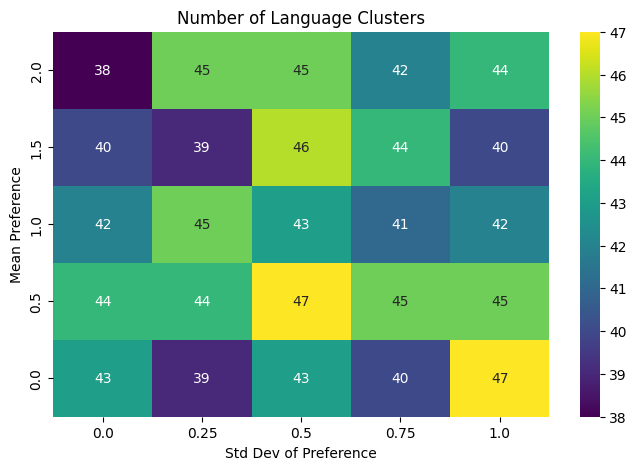

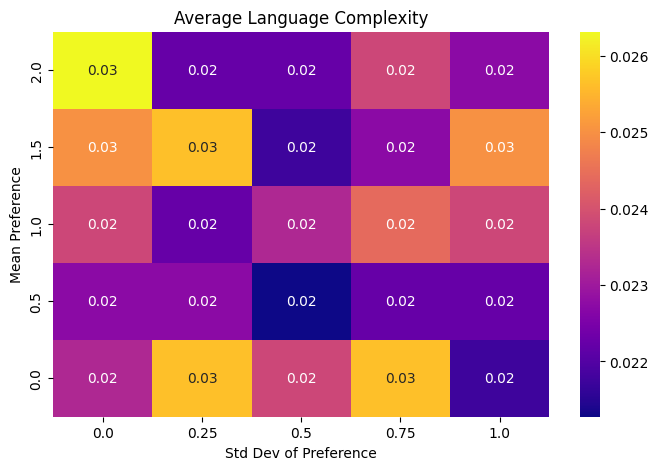

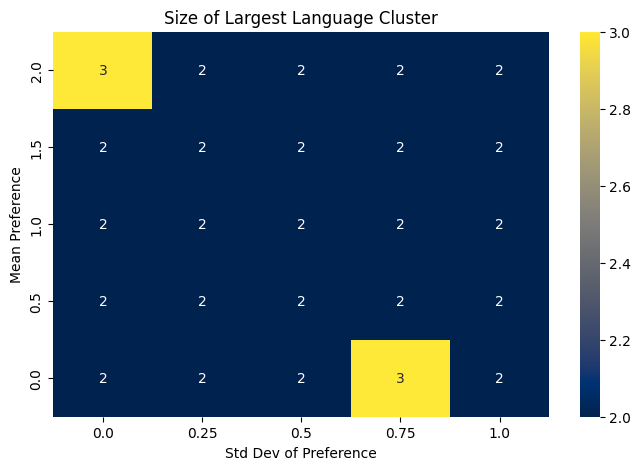

In [ ]:
# Convert results to dataframe and plot heatmaps
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame(results)

# Plot number of clusters
plt.figure(figsize=(8, 5))
sns.heatmap(df.pivot(index='mean', columns='std', values='clusters'), annot=True, fmt='d', cmap='viridis')
plt.title('Number of Language Clusters')
plt.xlabel('Std Dev of Preference')
plt.ylabel('Mean Preference')
plt.gca().invert_yaxis()
plt.show()

# Plot average complexity
plt.figure(figsize=(8, 5))
sns.heatmap(df.pivot(index='mean', columns='std', values='avg_complexity'), annot=True, fmt='.2f', cmap='plasma')
plt.title('Average Language Complexity')
plt.xlabel('Std Dev of Preference')
plt.ylabel('Mean Preference')
plt.gca().invert_yaxis()
plt.show()

# Plot size of largest cluster
plt.figure(figsize=(8, 5))
sns.heatmap(df.pivot(index='mean', columns='std', values='largest_cluster'), annot=True, fmt='d', cmap='cividis')
plt.title('Size of Largest Language Cluster')
plt.xlabel('Std Dev of Preference')
plt.ylabel('Mean Preference')
plt.gca().invert_yaxis()
plt.show()

In [10]:
# Capture language cluster data (size and language complexity)
language_cluster_data = model.compute_complexity_by_interaction_share()

Initializing simulation...
Starting simulation with 50 agents in 11 groups...

Initial Group Cognitive Capabilities:
  Group 0 (D=0.05):
    - Only immediate local information processing
    - Individual optimization with competition fears
    - Expected: High extraction rates (~120-140%)
  Group 1 (D=0.05):
    - Only immediate local information processing
    - Individual optimization with competition fears
    - Expected: High extraction rates (~120-140%)
  Group 2 (D=0.11):
    - Only immediate local information processing
    - Individual optimization with competition fears
    - Expected: High extraction rates (~120-140%)
  Group 3 (D=0.05):
    - Only immediate local information processing
    - Individual optimization with competition fears
    - Expected: High extraction rates (~120-140%)
  Group 4 (D=0.11):
    - Only immediate local information processing
    - Individual optimization with competition fears
    - Expected: High extraction rates (~120-140%)
  Group 5 (D=0.10)

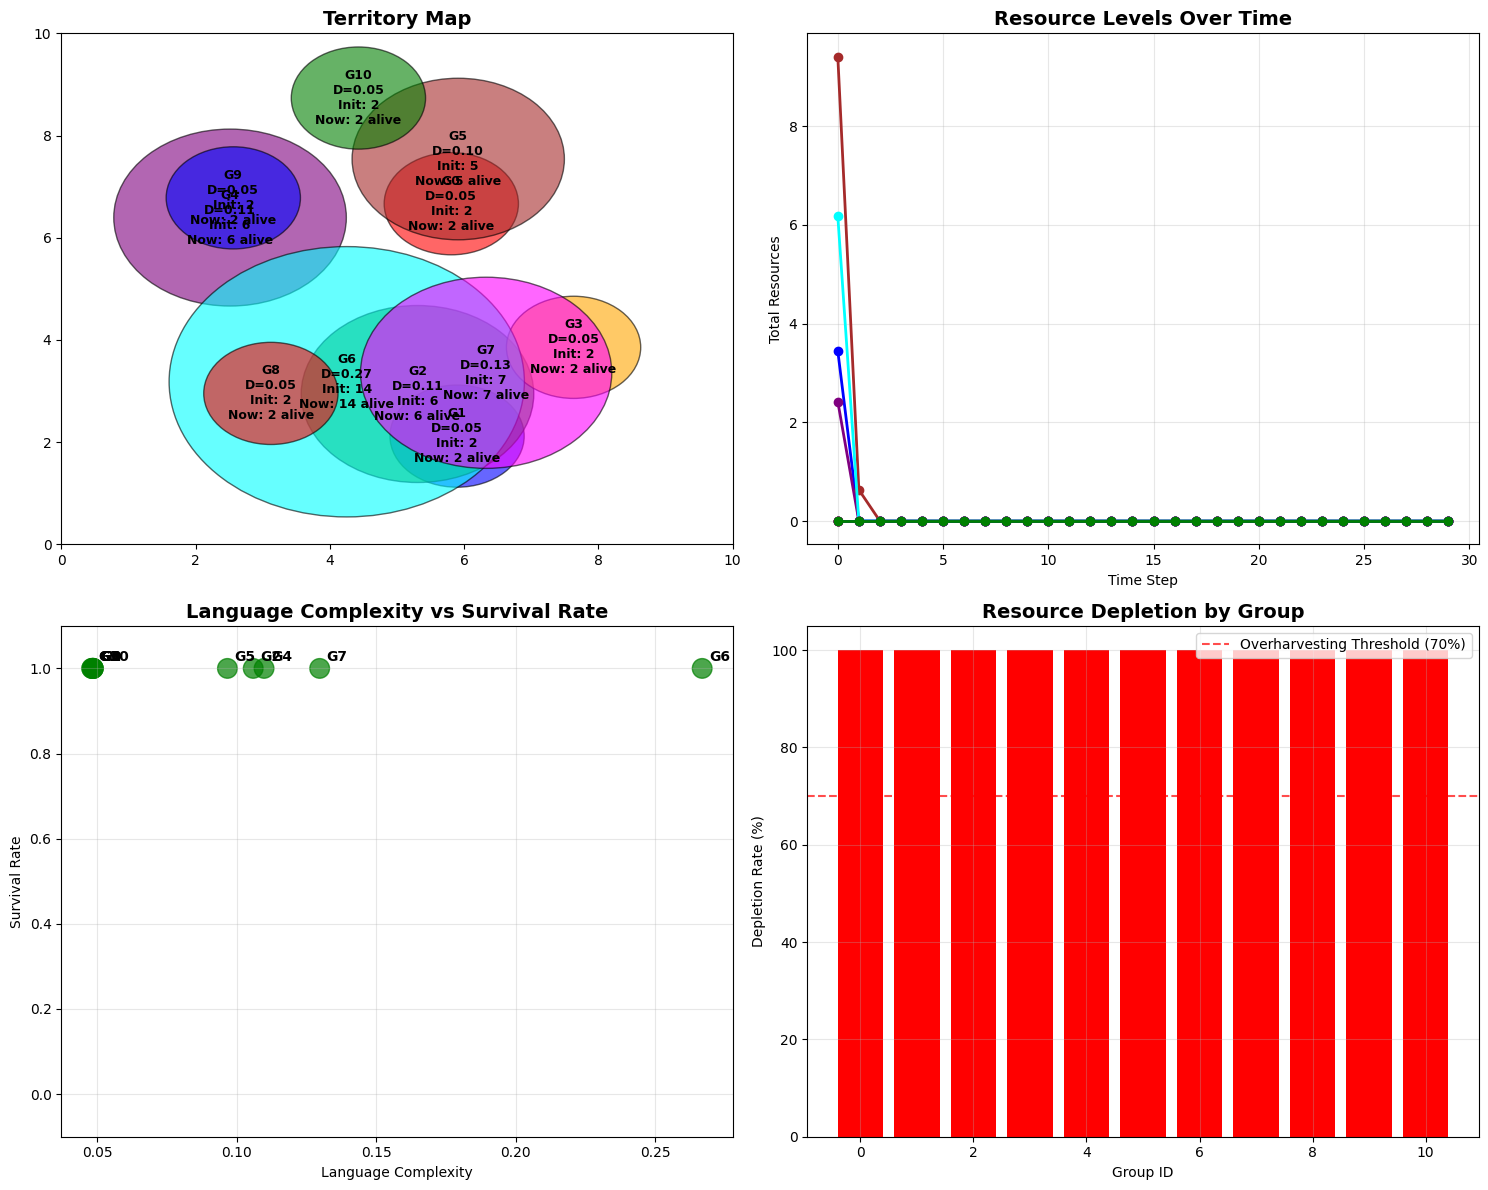

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
import random
from scipy.interpolate import griddata
import pandas as pd

def create_agent(agent_id, theta, group_id, language_complexity):
    return {
        'id': agent_id,
        'theta': theta,
        'group_id': group_id,
        'language_complexity': language_complexity,
        'alive': True
    }

def create_group(group_id, members, language_complexity, territory_center, territory_size, resources_A, resources_B):
    return {
        'id': group_id,
        'members': members,
        'language_complexity': language_complexity,
        'territory_center': territory_center,
        'territory_size': territory_size,
        'resources_A': resources_A,
        'resources_B': resources_B,
        'max_resources_A': resources_A,
        'max_resources_B': resources_B
    }

def initialize_simulation(language_cluster_data, forest_size=10, total_resources=1000):
    agents, groups = [], []
    agent_id = 0
    total_agents = sum(size for _, size in language_cluster_data.values())

    for group_id, (complexity, size) in language_cluster_data.items():
        group_members = []

        for _ in range(size):
            agent = create_agent(
                agent_id=agent_id,
                theta=np.random.beta(2, 2),
                group_id=group_id,
                language_complexity=complexity
            )
            agents.append(agent)
            group_members.append(agent)
            agent_id += 1

        territory_proportion = size / total_agents
        territory_size = np.sqrt(territory_proportion) * forest_size
        territory_center = (
            np.random.uniform(territory_size / 2, forest_size - territory_size / 2),
            np.random.uniform(territory_size / 2, forest_size - territory_size / 2)
        )

        resource_amount = territory_proportion * total_resources

        group = create_group(
            group_id=group_id,
            members=group_members,
            language_complexity=complexity,
            territory_center=territory_center,
            territory_size=territory_size,
            resources_A=resource_amount / 2,
            resources_B=resource_amount / 2
        )

        groups.append(group)

    return agents, groups

def calculate_emergent_extraction_strategy(agent, group, history, time_step):
    """
    Agents make extraction decisions based on information they can process
    and cognitive capabilities enabled by their language complexity.
    """
    D = agent['language_complexity']
    alive_members = [m for m in group['members'] if m['alive']]

    if not alive_members:
        return (0, 0)

    # Basic individual need calculation (all agents can do this)
    my_basic_need_A = agent['theta'] * 50  # Base daily need from fruit A
    my_basic_need_B = (1 - agent['theta']) * 50  # Base daily need from fruit B

    # INFORMATION PROCESSING SCOPE

    if D < 0.33:  # Low communication: immediate local information
        """
        - can only see and understand immediate local conditions.
        - cannot process abstract information about trends, future states,
        or group-level dynamics.
        """
        # only see current resource levels in immediate vicinity
        visible_resources_A = group['resources_A']
        visible_resources_B = group['resources_B']

        # individual optimization with competition fears
        competition_fear = 1.2

        # if resources seem scarce, increase competition
        total_visible = visible_resources_A + visible_resources_B
        total_group_needs = len(alive_members) * 50  # Everyone needs ~50 units

        if total_visible < total_group_needs * 2:  # If less than 2x needs available
            competition_fear = 1.4  # Increase competitive pressure

        desired_A = min(my_basic_need_A * competition_fear, visible_resources_A / len(alive_members))
        desired_B = min(my_basic_need_B * competition_fear, visible_resources_B / len(alive_members))

        return (desired_A, desired_B)

    elif D < 0.67:  # Medium communication: can process trends and group information
        """
        -can understand group-level information and short-term trends.
        -can coordinate with others and see patterns, but cannot engage in
        complex long-term planning or abstract reasoning about sustainability.
        """
        # see group-level resource state and coordinate with others
        total_group_need_A = sum(member['theta'] * 50 for member in alive_members)
        total_group_need_B = sum((1 - member['theta']) * 50 for member in alive_members)

        # can process short-term trends if history available
        trend_adjustment = 1.0
        if len(history) >= 2:
            # Look at recent resource changes to adjust behavior
            recent_states = [state for state in history[-3:] if 'groups' in state]
            if len(recent_states) >= 2:
                group_data_now = next((g for g in recent_states[-1]['groups'] if g['id'] == group['id']), None)
                group_data_before = next((g for g in recent_states[-2]['groups'] if g['id'] == group['id']), None)

                if group_data_now and group_data_before:
                    resource_change = group_data_now['resources'] - group_data_before['resources']
                    if resource_change < -20:  # Resources declining rapidly
                        trend_adjustment = 0.8  # Reduce extraction when seeing decline
                    elif resource_change > 20:  # Resources increasing
                        trend_adjustment = 1.1  # Can extract more when growing

        # Allocate based on proportional needs with trend adjustment
        if total_group_need_A > 0:
            my_share_A = (my_basic_need_A / total_group_need_A) * group['resources_A'] * trend_adjustment
        else:
            my_share_A = 0

        if total_group_need_B > 0:
            my_share_B = (my_basic_need_B / total_group_need_B) * group['resources_B'] * trend_adjustment
        else:
            my_share_B = 0

        return (my_share_A, my_share_B)

    else:  # high communication: abstract reasoning and long-term planning
        """
        -can engage in abstract reasoning about sustainability,
        model future scenarios, and coordinate complex group decisions.
        """

        # Calculate group carrying capacity based on resource regeneration
        regen_rate = 0.1  # can observe/understand regeneration patterns
        current_total_resources = group['resources_A'] + group['resources_B']
        max_total_resources = group['max_resources_A'] + group['max_resources_B']

        # LONG-TERM PLANNING: what happens under different extraction scenarios

        # Calculate what group needs vs. what's available
        total_group_needs = sum((member['theta'] * 50 + (1-member['theta']) * 50) for member in alive_members)
        current_extraction_rate = total_group_needs / current_total_resources if current_total_resources > 0 else 1

        # Project future resource levels
        projected_resources_next_turn = current_total_resources * (1 - current_extraction_rate + regen_rate)

        # COLLECTIVE DECISION MAKING

        # Calculate sustainable extraction rate that maintains resources over time
        sustainable_extraction_rate = regen_rate * 0.8  # leave safety margin
        sustainable_total_extraction = current_total_resources * sustainable_extraction_rate

        # FUTURE-ORIENTED VALUE SYSTEM: Weight future survival vs immediate satisfaction

        # If projected future is dire, prioritize conservation
        future_scarcity_factor = 1.0
        if projected_resources_next_turn < current_total_resources * 0.3:  # Disaster scenario
            future_scarcity_factor = 0.5  # Heavy conservation
        elif projected_resources_next_turn < current_total_resources * 0.6:  # Concerning scenario
            future_scarcity_factor = 0.7  # Moderate conservation

        # SOPHISTICATED ALLOCATION: Implement complex fairness and efficiency

        total_group_need_A = sum(member['theta'] * 50 for member in alive_members)
        total_group_need_B = sum((1 - member['theta']) * 50 for member in alive_members)

        # Allocate sustainable total based on proportional needs and future planning
        sustainable_A_pool = sustainable_total_extraction * (group['resources_A'] / current_total_resources) if current_total_resources > 0 else 0
        sustainable_B_pool = sustainable_total_extraction * (group['resources_B'] / current_total_resources) if current_total_resources > 0 else 0

        if total_group_need_A > 0:
            my_share_A = (my_basic_need_A / total_group_need_A) * sustainable_A_pool * future_scarcity_factor
        else:
            my_share_A = 0

        if total_group_need_B > 0:
            my_share_B = (my_basic_need_B / total_group_need_B) * sustainable_B_pool * future_scarcity_factor
        else:
            my_share_B = 0

        return (my_share_A, my_share_B)

def extract_resources(groups, history, time_step):
    """
    passes history and time_step to enable emergent decision-making
    """
    for group in groups:
        alive_members = [member for member in group['members'] if member['alive']]
        if not alive_members:
            continue

        total_extraction_A = 0
        total_extraction_B = 0
        for agent in alive_members:
            desired_A, desired_B = calculate_emergent_extraction_strategy(agent, group, history, time_step)
            actual_A = min(desired_A, group['resources_A'] - total_extraction_A)
            actual_B = min(desired_B, group['resources_B'] - total_extraction_B)
            total_extraction_A += max(0, actual_A)
            total_extraction_B += max(0, actual_B)

        # Calculate and print extraction rate for verification
        total_available = group['resources_A'] + group['resources_B']
        total_extracted = total_extraction_A + total_extraction_B
        extraction_rate = total_extracted / total_available if total_available > 0 else 0

        print(f"  Group {group['id']} (D={group['language_complexity']:.2f}): "
              f"Extracted {extraction_rate:.1%} of available resources "
              f"({total_extracted:.1f} out of {total_available:.1f})")

        group['resources_A'] = max(0, group['resources_A'] - total_extraction_A)
        group['resources_B'] = max(0, group['resources_B'] - total_extraction_B)

def check_overharvesting_and_explore(groups, history, time_step):
    for group in groups:
        alive_members = [member for member in group['members'] if member['alive']]
        if not alive_members:
            continue
        resource_depletion = 1 - (group['resources_A'] + group['resources_B']) / (group['max_resources_A'] + group['max_resources_B'])
        if resource_depletion > 0.9:
            initiate_conflict(group, groups, history, time_step)

def initiate_conflict(attacking_group, groups, history, time_step):
    potential_targets = [g for g in groups
                        if g['id'] != attacking_group['id']
                        and any(member['alive'] for member in g['members'])
                        and (g['resources_A'] + g['resources_B']) > 50]
    if not potential_targets:
        return
    target_group = max(potential_targets, key=lambda g: g['resources_A'] + g['resources_B'])
    attacking_alive = [m for m in attacking_group['members'] if m['alive']]
    defending_alive = [m for m in target_group['members'] if m['alive']]
    attacking_strength = len(attacking_alive) * (1 + attacking_group['language_complexity'])
    defending_strength = len(defending_alive) * (1 + target_group['language_complexity'])
    attack_success_prob = attacking_strength / (attacking_strength + defending_strength)
    if np.random.random() < attack_success_prob:
        for member in target_group['members']:
            member['alive'] = False
        attacking_group['resources_A'] += target_group['resources_A'] * 0.8
        attacking_group['resources_B'] += target_group['resources_B'] * 0.8
        attacking_group['max_resources_A'] += target_group['max_resources_A']
        attacking_group['max_resources_B'] += target_group['max_resources_B']
        attacking_group['territory_size'] += target_group['territory_size'] * 0.9
        history.append({
            'time': time_step,
            'event': 'conflict',
            'attacker': attacking_group['id'],
            'target': target_group['id'],
            'success': True
        })
    else:
        casualties = max(1, len(attacking_alive) // 3)
        for i in range(min(casualties, len(attacking_alive))):
            attacking_alive[i]['alive'] = False
        history.append({
            'time': time_step,
            'event': 'conflict',
            'attacker': attacking_group['id'],
            'target': target_group['id'],
            'success': False
        })

def regenerate_resources(groups):
    for group in groups:
        alive_members = [member for member in group['members'] if member['alive']]
        if alive_members:
            regen_rate = 0.1
            group['resources_A'] += regen_rate * group['resources_A'] * (1 - group['resources_A'] / group['max_resources_A'])
            group['resources_B'] += regen_rate * group['resources_B'] * (1 - group['resources_B'] / group['max_resources_B'])
            group['resources_A'] = min(group['resources_A'], group['max_resources_A'])
            group['resources_B'] = min(group['resources_B'], group['max_resources_B'])

def run_simulation_step(groups, history, time_step):
    print(f"\nStep {time_step + 1} - Resource Extraction:")
    extract_resources(groups, history, time_step)  # Pass history for emergent decisions
    check_overharvesting_and_explore(groups, history, time_step)
    regenerate_resources(groups)
    state = {
        'time': time_step,
        'groups': [{
            'id': g['id'],
            'alive_members': len([m for m in g['members'] if m['alive']]),
            'language_complexity': g['language_complexity'],
            'resources': g['resources_A'] + g['resources_B'],
            'territory_size': g['territory_size']
        } for g in groups if any(m['alive'] for m in g['members'])]
    }
    history.append(state)

def run_full_simulation(language_cluster_data, steps=30):
    print("Initializing simulation...")
    agents, groups = initialize_simulation(language_cluster_data)
    history = []
    print(f"Starting simulation with {len(agents)} agents in {len(groups)} groups...")

    print("\nInitial Group Cognitive Capabilities:")
    for group in groups:
        D = group['language_complexity']
        print(f"  Group {group['id']} (D={D:.2f}):")
        if D < 0.33:
            print("    - Only immediate local information processing")
            print("    - Individual optimization with competition fears")
            print("    - Expected: High extraction rates (~120-140%)")
        elif D < 0.67:
            print("    - Group-level information integration")
            print("    - Short-term trend recognition")
            print("    - Expected: Moderate extraction with trend adjustments (~80-100%)")
        else:
            print("    - Abstract reasoning (sustainability, carrying capacity)")
            print("    - Long-term scenario modeling and planning")
            print("    - Expected: Low extraction rates (~40-60%)")
    print()

    for step in range(steps):
        run_simulation_step(groups, history, step)
        alive_groups = [g for g in groups if any(m['alive'] for m in g['members'])]
        if len(alive_groups) <= 1:
            print(f"Simulation ended at step {step}: only one group remaining")
            break
    results = analyze_results(groups, history)
    return agents, groups, history, results

def analyze_results(groups, history):
    results = {}

    total_initial_resources = sum(g['max_resources_A'] + g['max_resources_B'] for g in groups)
    total_current_resources = sum(g['resources_A'] + g['resources_B'] for g in groups)
    overall_depletion = 1 - (total_current_resources / total_initial_resources)

    results['overall_depletion_rate'] = overall_depletion
    results['overharvesting_occurred'] = overall_depletion > 0.3

    group_analysis = []
    for group in groups:
        initial_resources = group['max_resources_A'] + group['max_resources_B']
        current_resources = group['resources_A'] + group['resources_B']
        depletion_rate = 1 - (current_resources / initial_resources) if initial_resources > 0 else 1

        group_analysis.append({
            'group_id': group['id'],
            'language_complexity': group['language_complexity'],
            'initial_size': len(group['members']),
            'current_size': len([m for m in group['members'] if m['alive']]),
            'depletion_rate': depletion_rate,
            'overharvested': depletion_rate > 0.7
        })

    results['group_analysis'] = group_analysis
    results['conflicts_total'] = len([r for r in history if isinstance(r, dict) and r.get('event') == 'conflict'])

    return results

def visualize_results(groups, history):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Territory map - Show all initial groups, not just survivors
    ax1.set_xlim(0, 10)
    ax1.set_ylim(0, 10)
    ax1.set_title('Territory Map', fontsize=14, fontweight='bold')

    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'cyan', 'magenta']

    for i, group in enumerate(groups):
        color = colors[i % len(colors)]

        # Draw territory circle for groups (initial state)
        circle = patches.Circle(group['territory_center'], group['territory_size']/2,
                              facecolor=color, alpha=0.6, edgecolor='black')
        ax1.add_patch(circle)

        # Show initial vs current status
        alive_members = [member for member in group['members'] if member['alive']]
        status = "EXTINCT" if len(alive_members) == 0 else f"{len(alive_members)} alive"

        ax1.text(group['territory_center'][0], group['territory_center'][1],
                f'G{group["id"]}\nD={group["language_complexity"]:.2f}\nInit: {len(group["members"])}\nNow: {status}',
                ha='center', va='center', fontsize=9, fontweight='bold')

    # 2. Resource levels over time - all groups with extinction events
    if len(history) > 1:
        times = []
        resource_data = {f'Group {g["id"]}': [] for g in groups}

        for record in history:
            if 'groups' in record:
                times.append(record['time'])
                # For each group, find its data or mark as extinct (0 resources)
                for g in groups:
                    group_data = next((item for item in record['groups'] if item['id'] == g['id']), None)
                    if group_data:
                        resource_data[f'Group {g["id"]}'].append(group_data['resources'])
                    else:
                        # Group is extinct - append 0
                        resource_data[f'Group {g["id"]}'].append(0)

        # Plot all groups, including extinct ones
        for i, (group_name, resources) in enumerate(resource_data.items()):
            if len(resources) == len(times):
                color = colors[i % len(colors)]
                # Use different line styles for extinct vs surviving groups
                group_id = int(group_name.split()[1])
                group = next(g for g in groups if g['id'] == group_id)
                alive_members = [member for member in group['members'] if member['alive']]

                if len(alive_members) == 0:
                    # Extinct group - dashed line
                    ax2.plot(times, resources, label=f'{group_name}',
                            color=color, linestyle='--', marker='x', linewidth=2, alpha=0.7)
                else:
                    # Surviving group - solid line
                    ax2.plot(times, resources, label=f'{group_name}',
                            color=color, marker='o', linewidth=2)

        ax2.set_title('Resource Levels Over Time', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Time Step')
        ax2.set_ylabel('Total Resources')
        # ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax2.grid(True, alpha=0.3)

    # 3. Language complexity vs survival rate
    if groups:
        complexities = [g['language_complexity'] for g in groups]
        survival_rates = [len([m for m in g['members'] if m['alive']]) / len(g['members']) for g in groups]

        # Color code by survival status
        colors_survival = ['red' if rate == 0 else 'orange' if rate < 1 else 'green' for rate in survival_rates]

        scatter = ax3.scatter(complexities, survival_rates, s=200, alpha=0.7, c=colors_survival)
        ax3.set_title('Language Complexity vs Survival Rate', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Language Complexity')
        ax3.set_ylabel('Survival Rate')
        ax3.grid(True, alpha=0.3)
        ax3.set_ylim(-0.1, 1.1)

        # Annotate all groups
        for i, group in enumerate(groups):
            ax3.annotate(f'G{group["id"]}', (complexities[i], survival_rates[i]),
                        xytext=(5, 5), textcoords='offset points', fontweight='bold')

    # 4. Resource depletion by group - Show ALL groups
    group_ids = [g['id'] for g in groups]
    depletion_rates = []

    for group in groups:
        initial_resources = group['max_resources_A'] + group['max_resources_B']
        current_resources = group['resources_A'] + group['resources_B']
        depletion_rate = 1 - (current_resources / initial_resources) if initial_resources > 0 else 1
        depletion_rates.append(depletion_rate * 100)

    # Color bars based on depletion severity
    bar_colors = ['red' if rate > 70 else 'orange' if rate > 50 else 'green' for rate in depletion_rates]
    bars = ax4.bar(group_ids, depletion_rates, color=bar_colors)

    ax4.set_title('Resource Depletion by Group', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Group ID')
    ax4.set_ylabel('Depletion Rate (%)')
    ax4.axhline(y=70, color='red', linestyle='--', alpha=0.7, label='Overharvesting Threshold (70%)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    # Add depletion percentage labels on bars
    # for bar, rate in zip(bars, depletion_rates):
    #     height = bar.get_height()
    #     ax4.text(bar.get_x() + bar.get_width()/2., height + 1,
    #             f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()

    return fig

def create_comprehensive_visualization(groups, history):
    """
    visualization including survival rates over time
    """
    fig = plt.figure(figsize=(20, 15))

    # Create a 3x2 subplot layout
    ax1 = plt.subplot(2, 3, 1)  # Territory map
    ax2 = plt.subplot(2, 3, 2)  # Resource levels over time
    ax3 = plt.subplot(2, 3, 3)  # Language complexity vs final survival rate
    ax4 = plt.subplot(2, 3, 4)  # Resource depletion by group
    ax5 = plt.subplot(2, 3, 5)  # Survival rates over time
    ax6 = plt.subplot(2, 3, 6)  # Group sizes over time

    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'cyan', 'magenta']

    # 1. Territory map - all initial groups
    ax1.set_xlim(0, 10)
    ax1.set_ylim(0, 10)
    ax1.set_title('Territory Map', fontsize=12, fontweight='bold')

    for i, group in enumerate(groups):
        color = colors[i % len(colors)]
        circle = patches.Circle(group['territory_center'], group['territory_size']/2,
                              facecolor=color, alpha=0.6, edgecolor='black')
        ax1.add_patch(circle)

        alive_members = [member for member in group['members'] if member['alive']]
        status = "extinct" if len(alive_members) == 0 else f"{len(alive_members)}"

        ax1.text(group['territory_center'][0], group['territory_center'][1],
                f'G{group["id"]}\nD={group["language_complexity"]:.2f}\n{len(group["members"])}→{status}',
                ha='center', va='center', fontsize=8, fontweight='bold')

    # 2. Resource levels over time
    if len(history) > 1:
        times = []
        resource_data = {f'Group {g["id"]}': [] for g in groups}

        for record in history:
            if 'groups' in record:
                times.append(record['time'])
                for g in groups:
                    group_data = next((item for item in record['groups'] if item['id'] == g['id']), None)
                    resource_data[f'Group {g["id"]}'].append(group_data['resources'] if group_data else 0)

        for i, (group_name, resources) in enumerate(resource_data.items()):
            if len(resources) == len(times):
                color = colors[i % len(colors)]
                group_id = int(group_name.split()[1])
                group = next(g for g in groups if g['id'] == group_id)
                alive_members = [member for member in group['members'] if member['alive']]

                linestyle = '--' if len(alive_members) == 0 else '-'
                alpha = 0.6 if len(alive_members) == 0 else 1.0

                ax2.plot(times, resources, label=group_name, color=color,
                        linestyle=linestyle, marker='o', linewidth=2, alpha=alpha)

        ax2.set_title('Resource Levels Over Time', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Time Step')
        ax2.set_ylabel('Total Resources')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

    # 3. Language complexity vs survival rate
    complexities = [g['language_complexity'] for g in groups]
    survival_rates = [len([m for m in g['members'] if m['alive']]) / len(g['members']) for g in groups]

    colors_survival = ['red' if rate == 0 else 'orange' if rate < 1 else 'green' for rate in survival_rates]
    ax3.scatter(complexities, survival_rates, s=200, alpha=0.7, c=colors_survival)
    ax3.set_title('Language Complexity vs Final Survival', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Language Complexity')
    ax3.set_ylabel('Survival Rate')
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim(-0.1, 1.1)

    for i, group in enumerate(groups):
        ax3.annotate(f'G{group["id"]}', (complexities[i], survival_rates[i]),
                    xytext=(5, 5), textcoords='offset points', fontweight='bold')

    # 4. Resource depletion by group
    group_ids = [g['id'] for g in groups]
    depletion_rates = []

    for group in groups:
        initial_resources = group['max_resources_A'] + group['max_resources_B']
        current_resources = group['resources_A'] + group['resources_B']
        depletion_rate = 1 - (current_resources / initial_resources) if initial_resources > 0 else 1
        depletion_rates.append(depletion_rate * 100)

    # mark overharversting by color
    bar_colors = ['red' if rate > 70 else 'orange' if rate > 50 else 'green' for rate in depletion_rates]
    bars = ax4.bar(group_ids, depletion_rates, color=bar_colors)

    ax4.set_title('Resource Depletion by Group', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Group ID')
    ax4.set_ylabel('Depletion Rate (%)')
    # ax4.axhline(y=70, color='red', linestyle='--', alpha=0.7, label='Overharvest (70%)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    for bar, rate in zip(bars, depletion_rates):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{rate:.0f}%', ha='center', va='bottom', fontweight='bold', fontsize=8)

    # 5. Survival rates over time
    if len(history) > 1:
        times = []
        survival_data = {f'Group {g["id"]}': [] for g in groups}

        for record in history:
            if 'groups' in record:
                times.append(record['time'])
                for g in groups:
                    group_data = next((item for item in record['groups'] if item['id'] == g['id']), None)
                    if group_data:
                        survival_rate = group_data['alive_members'] / len(g['members'])
                    else:
                        survival_rate = 0  # Group extinct
                    survival_data[f'Group {g["id"]}'].append(survival_rate)

        for i, (group_name, survival_rates_time) in enumerate(survival_data.items()):
            if len(survival_rates_time) == len(times):
                color = colors[i % len(colors)]
                ax5.plot(times, survival_rates_time, label=group_name, color=color,
                        marker='s', linewidth=2)

        ax5.set_title('Survival Rates Over Time', fontsize=12, fontweight='bold')
        ax5.set_xlabel('Time Step')
        ax5.set_ylabel('Survival Rate')
        ax5.set_ylim(-0.1, 1.1)
        ax5.legend()
        ax5.grid(True, alpha=0.3)

    # 6. Group sizes over time
    if len(history) > 1:
        for i, (group_name, survival_rates_time) in enumerate(survival_data.items()):
            if len(survival_rates_time) == len(times):
                color = colors[i % len(colors)]
                group_id = int(group_name.split()[1])
                group = next(g for g in groups if g['id'] == group_id)
                group_sizes = [rate * len(group['members']) for rate in survival_rates_time]

                ax6.plot(times, group_sizes, label=group_name, color=color,
                        marker='o', linewidth=2)

        ax6.set_title('Group Sizes Over Time', fontsize=12, fontweight='bold')
        ax6.set_xlabel('Time Step')
        ax6.set_ylabel('Number of Alive Members')
        ax6.legend()
        ax6.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

def main(language_cluster_data):
    np.random.seed(42)
    random.seed(42)

    agents, groups, history, results = run_full_simulation(language_cluster_data)

    print("\n=== SIMULATION RESULTS ===")
    print(f"Overall resource depletion: {results['overall_depletion_rate']:.1%}")
    print(f"Overharvesting occurred: {results['overharvesting_occurred']}")
    print(f"Total conflicts: {results['conflicts_total']}")

    print(f"\n=== GROUP ANALYSIS ===")
    for group in results['group_analysis']:
        status = "EXTINCT" if group['current_size'] == 0 else f"{group['current_size']} alive"
        overharvest_status = "OVERHARVESTED" if group['overharvested'] else "Sustainable"
        print(f"Group {group['group_id']}: "
              f"D={group['language_complexity']:.2f}, "
              f"Size: {group['initial_size']}→{status}, "
              f"Depletion: {group['depletion_rate']:.1%} ({overharvest_status})")

    # Create both visualizations
    fig1 = visualize_results(groups, history)  # Original 2x2 layout
    # fig2 = create_comprehensive_visualization(groups, history)  # New 2x3 layout

    plt.show()

    return agents, groups, history, results



if __name__ == "__main__":
    # agents, groups, history, results = main()
    main(language_cluster_data)

In [ ]:
# Comparative statics using inputs to first model and outputs from second model

results_emergent = []

for mu in means:
    for sigma in stds:
        # Run language model
        model = AgentModel(
            num_agents=num_agents,
            grid_size=grid_size,
            repeat_pref_mean=mu,
            repeat_pref_std=sigma,
            interaction_radius=interaction_radius,
            min_shared=min_shared,
            threshold_start=threshold_start,
            decay_rate=decay_rate,
            max_shared_weight=max_shared_weight,
            move_strength=move_strength,
            max_movement=max_movement,
            language_cluster_threshold=language_cluster_threshold
        )

        # Run the first model
        for _ in range(num_steps):
            model.interact(min_shared=min_shared, threshold_start=threshold_start, interaction_radius=interaction_radius)
            model.decay_and_reinforce(decay=decay_rate, max_weight=max_shared_weight)
            model.move_agents(strength=move_strength, max_step=max_movement)

        # Extract language cluster data
        language_cluster_data = model.compute_complexity_by_interaction_share()

        # Run the second model
        _, _, _, results = run_full_simulation(language_cluster_data)

        # Capture overharvesting rate (proportion of groups with >70% depletion)
        overharvested = [g for g in results['group_analysis'] if g['overharvested']]
        total_groups = len(results['group_analysis'])
        proportion_overharvested = len(overharvested) / total_groups if total_groups > 0 else np.nan

        results_emergent.append({
            'mean': mu,
            'std': sigma,
            'proportion_overharvested': proportion_overharvested
        })

Initializing simulation...
Starting simulation with 50 agents in 2 groups...

Initial Group Cognitive Capabilities:
  Group 0 (D=0.35):
    - Group-level information integration
    - Short-term trend recognition
    - Expected: Moderate extraction with trend adjustments (~80-100%)
  Group 1 (D=0.65):
    - Group-level information integration
    - Short-term trend recognition
    - Expected: Moderate extraction with trend adjustments (~80-100%)


Step 1 - Resource Extraction:
  Group 0 (D=0.35): Extracted 100.0% of available resources (360.0 out of 360.0)
  Group 1 (D=0.65): Extracted 100.0% of available resources (640.0 out of 640.0)

Step 2 - Resource Extraction:
  Group 0 (D=0.35): Extracted 0.0% of available resources (0.0 out of 0.0)
  Group 1 (D=0.65): Extracted 100.0% of available resources (0.0 out of 0.0)

Step 3 - Resource Extraction:
  Group 0 (D=0.35): Extracted 0.0% of available resources (0.0 out of 0.0)
  Group 1 (D=0.65): Extracted 100.0% of available resources (0.0 ou

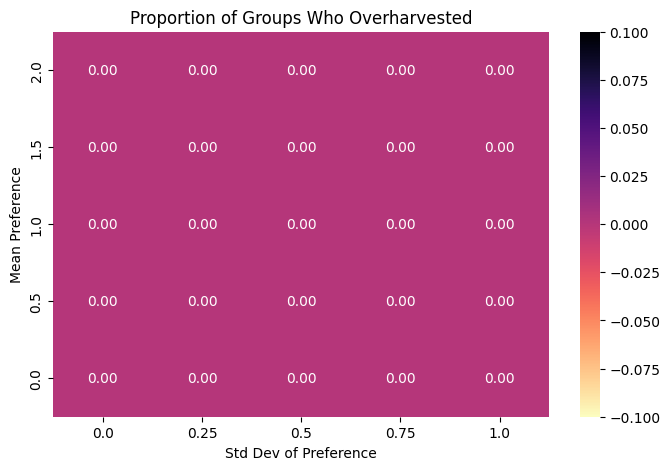

In [ ]:
# Convert to dataframe and plot

df_emergent = pd.DataFrame(results_emergent)

plt.figure(figsize=(8, 5))
sns.heatmap(
    df_emergent.pivot(index='mean', columns='std', values='proportion_overharvested'),
    annot=True, fmt='.2f', cmap='magma_r'
)
plt.title('Proportion of Groups Who Overharvested')
plt.xlabel('Std Dev of Preference')
plt.ylabel('Mean Preference')
plt.gca().invert_yaxis()
plt.show()